<a href="https://colab.research.google.com/github/GUHAN-001/Employee-Attrition-Prediction/blob/main/Employee_Attrition_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
import pandas as pd
from google.colab import files

# Upload file
uploaded = files.upload()

# Replace with your CSV file name
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Display first 5 rows
df.head()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition (1).csv


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
print(df.shape)

df.info()

df.isnull().sum()

(1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel     

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


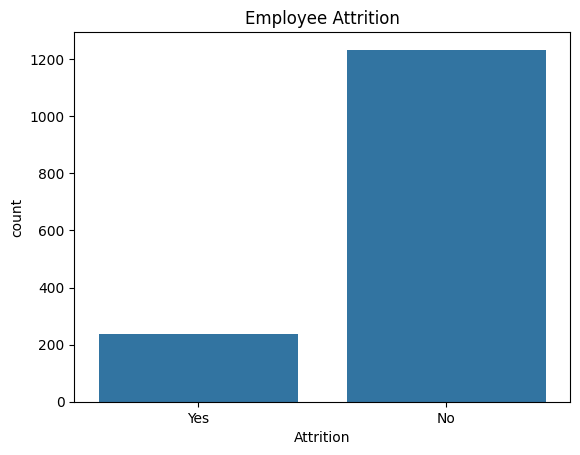

In [8]:
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition")
plt.show()

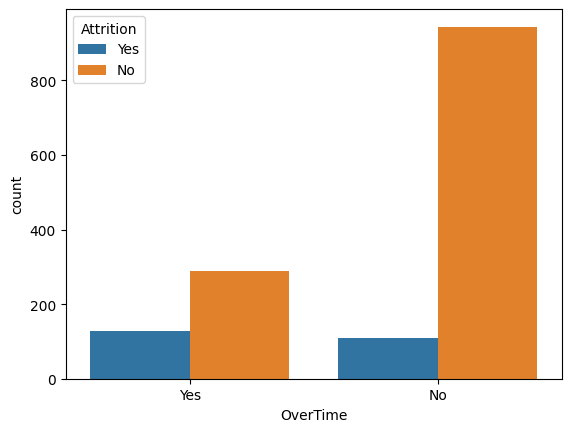

In [9]:
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.show()

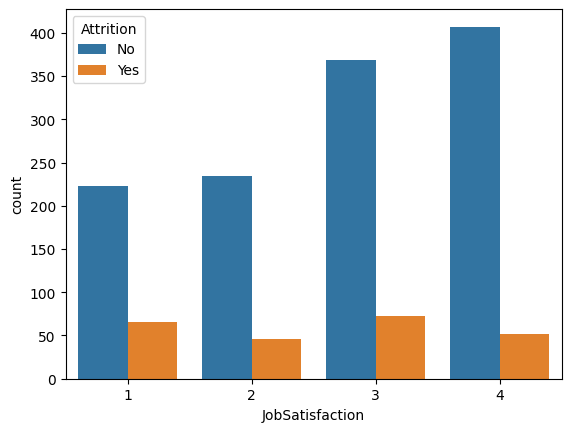

In [10]:
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)
plt.show()

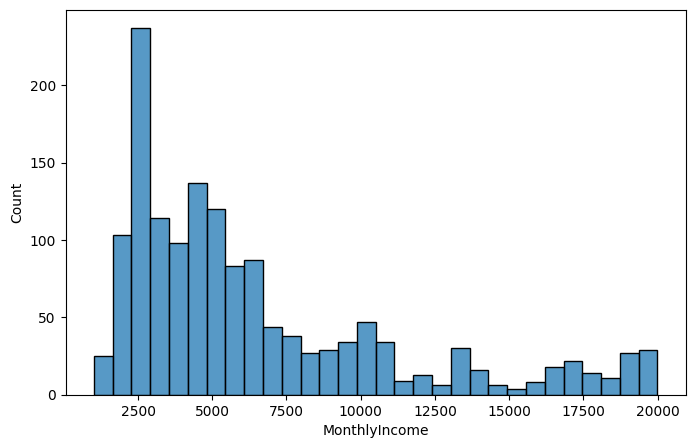

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyIncome'], bins=30)
plt.show()

In [13]:
features = [
    'Age',
    'DistanceFromHome',
    'JobSatisfaction',
    'MonthlyIncome',
    'OverTime',
    'YearsAtCompany',
    'YearsSinceLastPromotion',
    'WorkLifeBalance'
]

X = df[features]
y = df['Attrition']

In [14]:
le = LabelEncoder()

X['OverTime'] = le.fit_transform(X['OverTime'])

y = le.fit_transform(y)

/tmp/ipykernel_3460/3223336926.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['OverTime'] = le.fit_transform(X['OverTime'])


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [17]:
y_pred = model.predict(X_test)

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8639455782312925


In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.45      0.13      0.20        39

    accuracy                           0.86       294
   macro avg       0.67      0.55      0.56       294
weighted avg       0.82      0.86      0.83       294



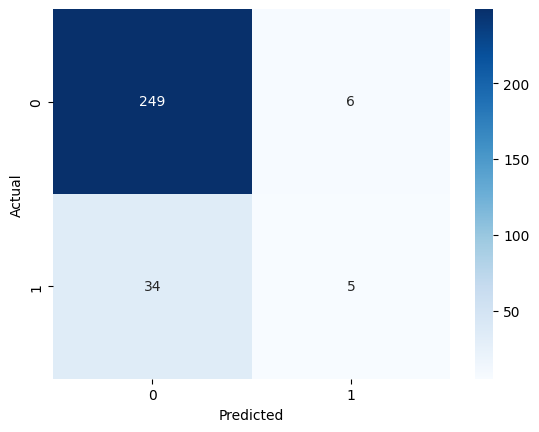

In [20]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
# Create cleaned dataset
cleaned_df = X.copy()
cleaned_df['Attrition'] = y

# Save as CSV
cleaned_df.to_csv('employee_attrition_cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [21]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                   Feature  Importance
3            MonthlyIncome    0.251216
0                      Age    0.171486
1         DistanceFromHome    0.148966
5           YearsAtCompany    0.135042
4                 OverTime    0.084568
6  YearsSinceLastPromotion    0.074786
2          JobSatisfaction    0.069334
7          WorkLifeBalance    0.064602


In [22]:
new_employee = [[
    28,      # Age
    15,      # DistanceFromHome
    2,       # JobSatisfaction
    3500,    # MonthlyIncome
    1,       # OverTime
    2,       # YearsAtCompany
    0,       # YearsSinceLastPromotion
    2        # WorkLifeBalance
]]

prediction = model.predict(new_employee)

if prediction[0] == 1:
    print("Employee likely to leave")
else:
    print("Employee likely to stay")

Employee likely to stay


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [23]:
import joblib

joblib.dump(model, 'employee_attrition_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Model Saved Successfully")

Model Saved Successfully


In [24]:
from google.colab import files

files.download('employee_attrition_model.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
from google.colab import files

files.download('employee_attrition_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>